In [ ]:
import os
from PIL import Image
from joblib import dump, load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from patches import get_image_patches, get_images

In [2]:
images = get_images(
    source_pattern=os.path.join("..", "data", "artwork", "**"),
    skip=None
)

In [3]:
class ColorEncoder:

    def __init__(
            self, 
            n_bins_per_dim: int = 25,
            noise: int = 0
    ):
        
        self.n_bins_per_dim = n_bins_per_dim
        self.noise = noise

        self._bins = np.linspace(0, 255, 25)

    def encode(self, q: np.ndarray):

        q = np.array(q, dtype=np.uint32)
        q = q + self.noise * np.random.random(q.shape)
        q = np.clip(q, 0, 255)
        q = q.reshape( -1, 3)

        q = np.histogramdd(q, bins=(self._bins, ) * 3)[0].flatten()
        return q / sum(q)

In [4]:
encoder = ColorEncoder()

In [5]:
F = []
index = []
for file, x in images:
    features = encoder.encode(x)
    F.append(features)
    index.append(file)

  0%|          | 0/43906 [00:00<?, ?it/s]

In [6]:
F = pd.DataFrame(F, index=index).convert_dtypes(dtype_backend="pyarrow")
F.to_parquet(os.path.join("..", "data", "vectors.parquet"))
F = pd.read_parquet(os.path.join("..", "data", "vectors.parquet"))

In [19]:
F.shape

(43906, 13824)

In [79]:
test_images = get_images(
    source_pattern=os.path.join("..", "data", "query", "1593061474_aa01.jpg"),
    skip=None
)

for file, q in test_images:
    Ft = encoder.encode(q)
    break

  0%|          | 0/1 [00:00<?, ?it/s]

In [83]:
weights = np.ones(F.shape[1])
weights[0] = 1e-2

log_loss =  abs(F - Ft).dot((weights * Ft)[:, np.newaxis])

In [84]:
weights

array([0.01, 1.  , 1.  , ..., 1.  , 1.  , 1.  ], shape=(13824,))

In [85]:
files = log_loss.sort_values(0).head(40)
files

,0
../data/artwork/d61f670e-8e4c-493f-bef0-c4c7b0bcd288.jpg,0.001713
../data/artwork/d183cc80-a9ce-4290-bf65-f8202f508ac0.jpg,0.001869
../data/artwork/6b3f3fbb-0188-4eec-90c0-81c801d3a996.jpg,0.002833
../data/artwork/b82f763a-c960-4b59-8c77-f3bea7bd8c8b.jpg,0.002929
../data/artwork/293ce819-c228-4ff1-827c-3d0cbed703ea.jpg,0.003384
../data/artwork/51392ece-c9f5-46b0-9dce-0a1a0343a536.jpg,0.003489
../data/artwork/d00efb55-a859-408c-b727-6914584c06d2.jpg,0.003501
../data/artwork/715afdde-ef3b-40c0-8b1d-59c59381a54e.jpg,0.003637
../data/artwork/2c6b7b40-e7c5-402b-a39f-97fc236c9a89.jpg,0.003709
../data/artwork/f9154d2a-3fc5-4fd6-9885-a810cb6b542a.jpg,0.003709


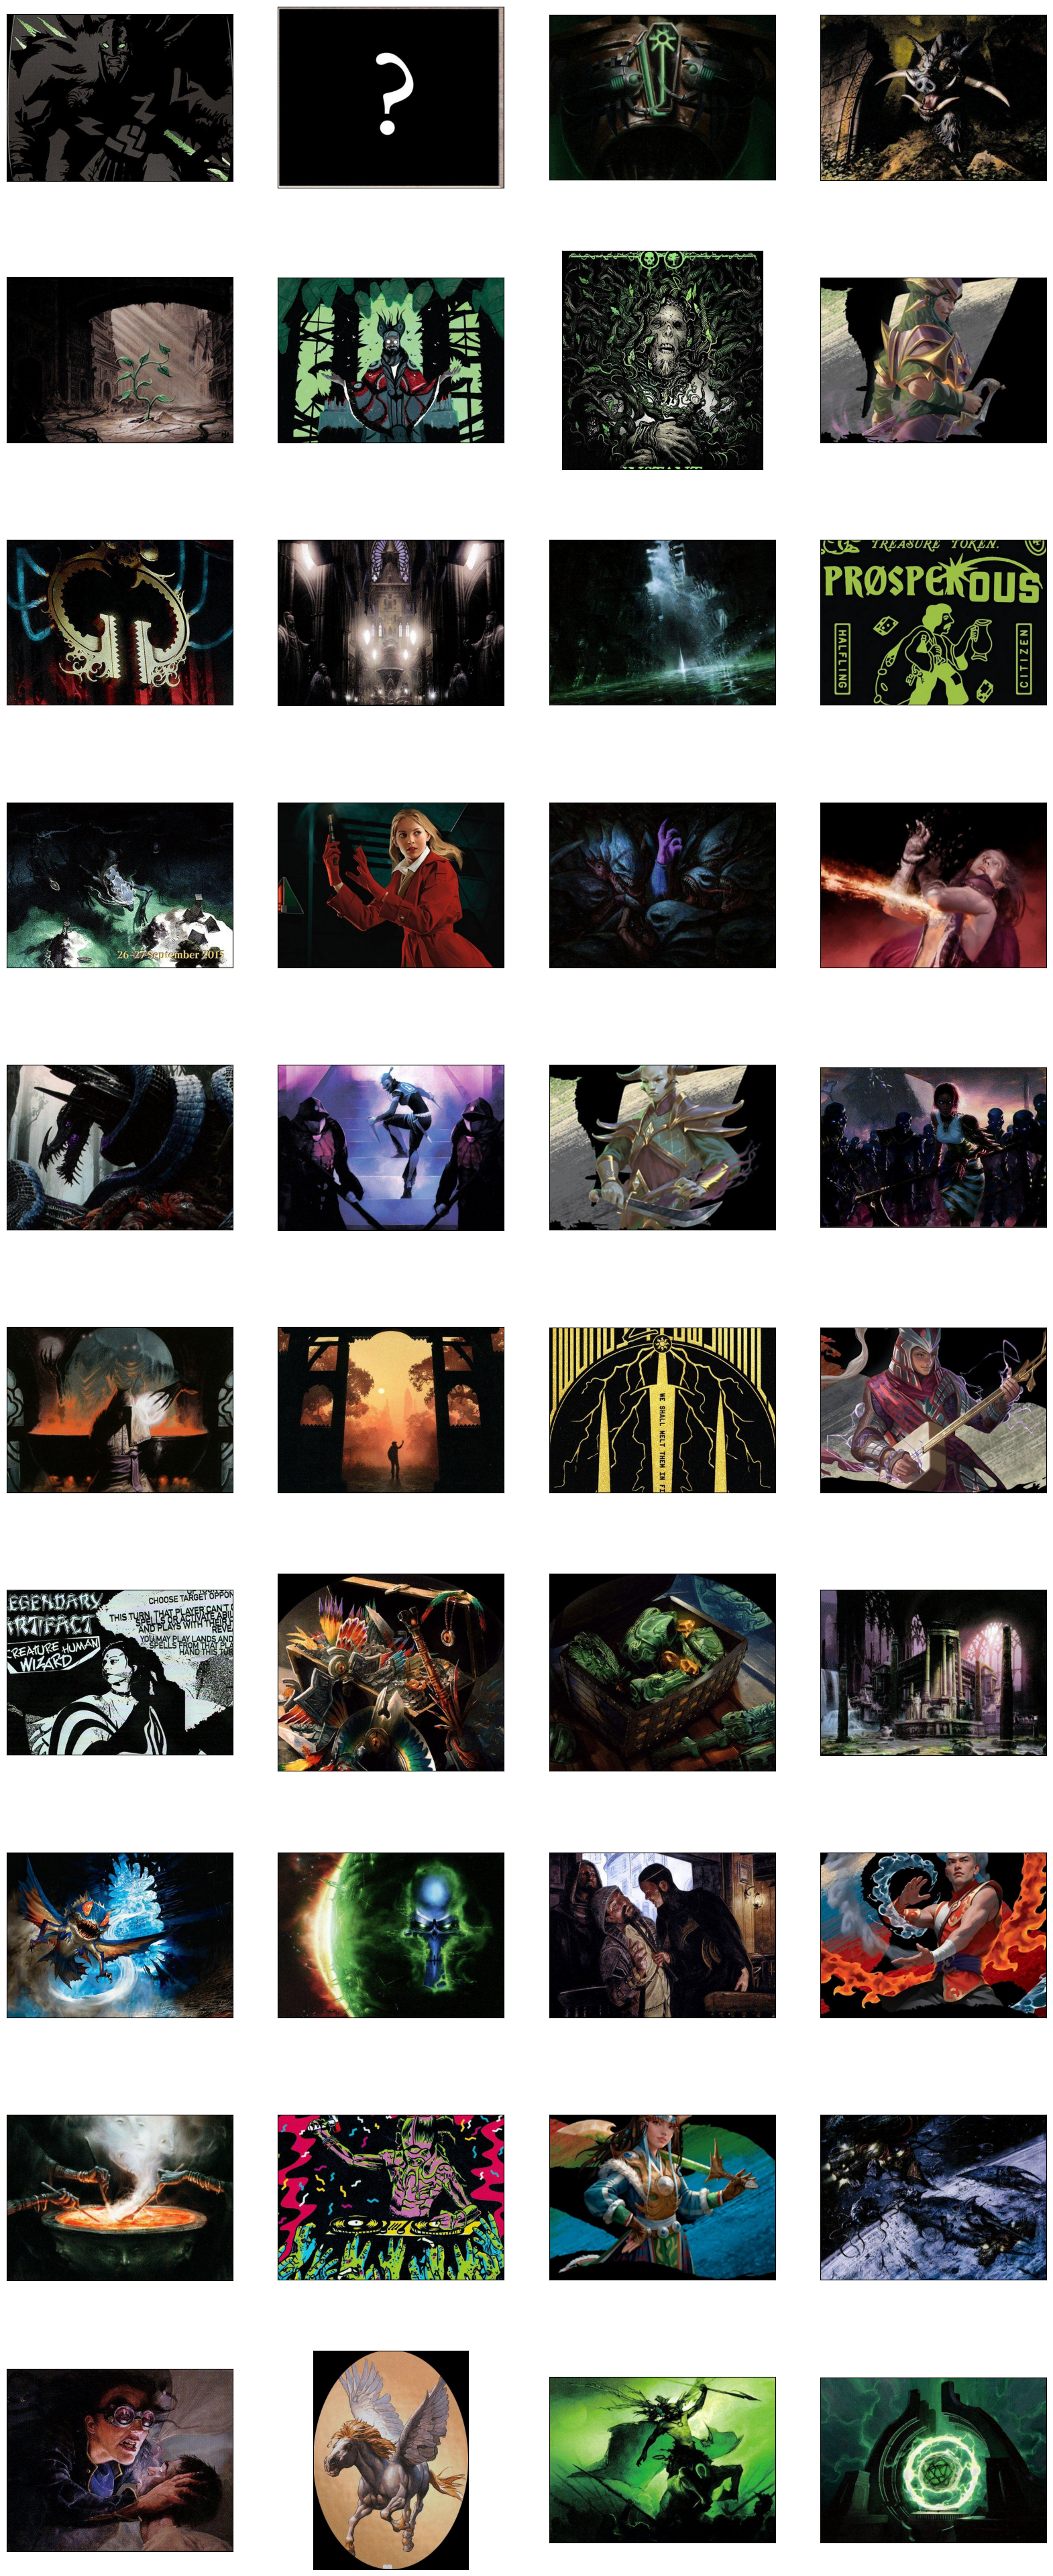

In [87]:
f, ax = plt.subplots(ncols=4, nrows=10, figsize=(20, 50))
for i, file in enumerate(files.index):
    col = i // 4
    row = i % 4
    s = Image.open(file)
    s = np.array(s)
    ax[col, row].imshow(s)
    ax[col, row].axes.get_xaxis().set_ticks([])
    ax[col, row].axes.get_yaxis().set_ticks([])

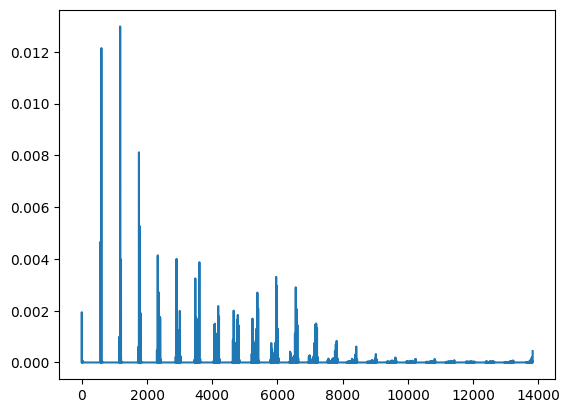

In [82]:
plt.plot(weights * Ft)